Aqui está o **Statement** formatado seguindo o padrão rigoroso do HackerRank para o problema **Even Tree** (ou **Even Forest**), baseado nas especificações e lógica discutidas nos seus planos.

---

# Even Tree

Você recebe uma árvore (um grafo conectado sem ciclos) com **$N$** nós e **$M$** arestas. Os nós são numerados de **$1$** a **$N$**. Sua tarefa é remover o número máximo de arestas da árvore de modo que cada componente conectado da "floresta" resultante contenha um número **par** de nós.

### Input Format

A primeira linha contém dois inteiros separados por espaço, **$N$** (número de nós) e **$M$** (número de arestas).
Cada uma das próximas **$M$** linhas contém dois inteiros separados por espaço, **$u$** e **$v$**, que representam uma aresta entre o nó **$u$** e o nó **$v$**.

### Constraints

*   $2 \leq N \leq 100$
*   $M = N - 1$ (A estrutura é sempre uma árvore)
*   É garantido que $N$ é um número **par** para que uma solução válida exista.

### Output Format

Imprima um único inteiro representando o número máximo de arestas que podem ser removidas para formar uma floresta onde cada árvore tenha um número par de nós.

---

### Sample Input

```text
10 9
2 1
3 1
4 3
5 2
6 1
7 2
8 6
9 8
10 8
```

### Sample Output

```text
2
```

### Explanation

Considere a árvore fornecida no exemplo:
1.  Removendo a aresta entre o nó **$1$** e o nó **$3$**, a subárvore enraizada em **$3$** conterá os nós **$\{3, 4\}$** (tamanho $2$, que é par).
2.  Removendo a aresta entre o nó **$1$** e o nó **$6$**, a subárvore enraizada em **$6$** conterá os nós **$\{6, 8, 9, 10\}$** (tamanho $4$, que é par).
3.  O componente restante conectado ao nó raiz **$1$** conterá os nós **$\{1, 2, 5, 7\}$** (tamanho $4$, que é par).

O número total de arestas removidas é **$2$**. Note que qualquer outra tentativa de remover mais arestas resultaria em pelo menos um componente com um número ímpar de nós.

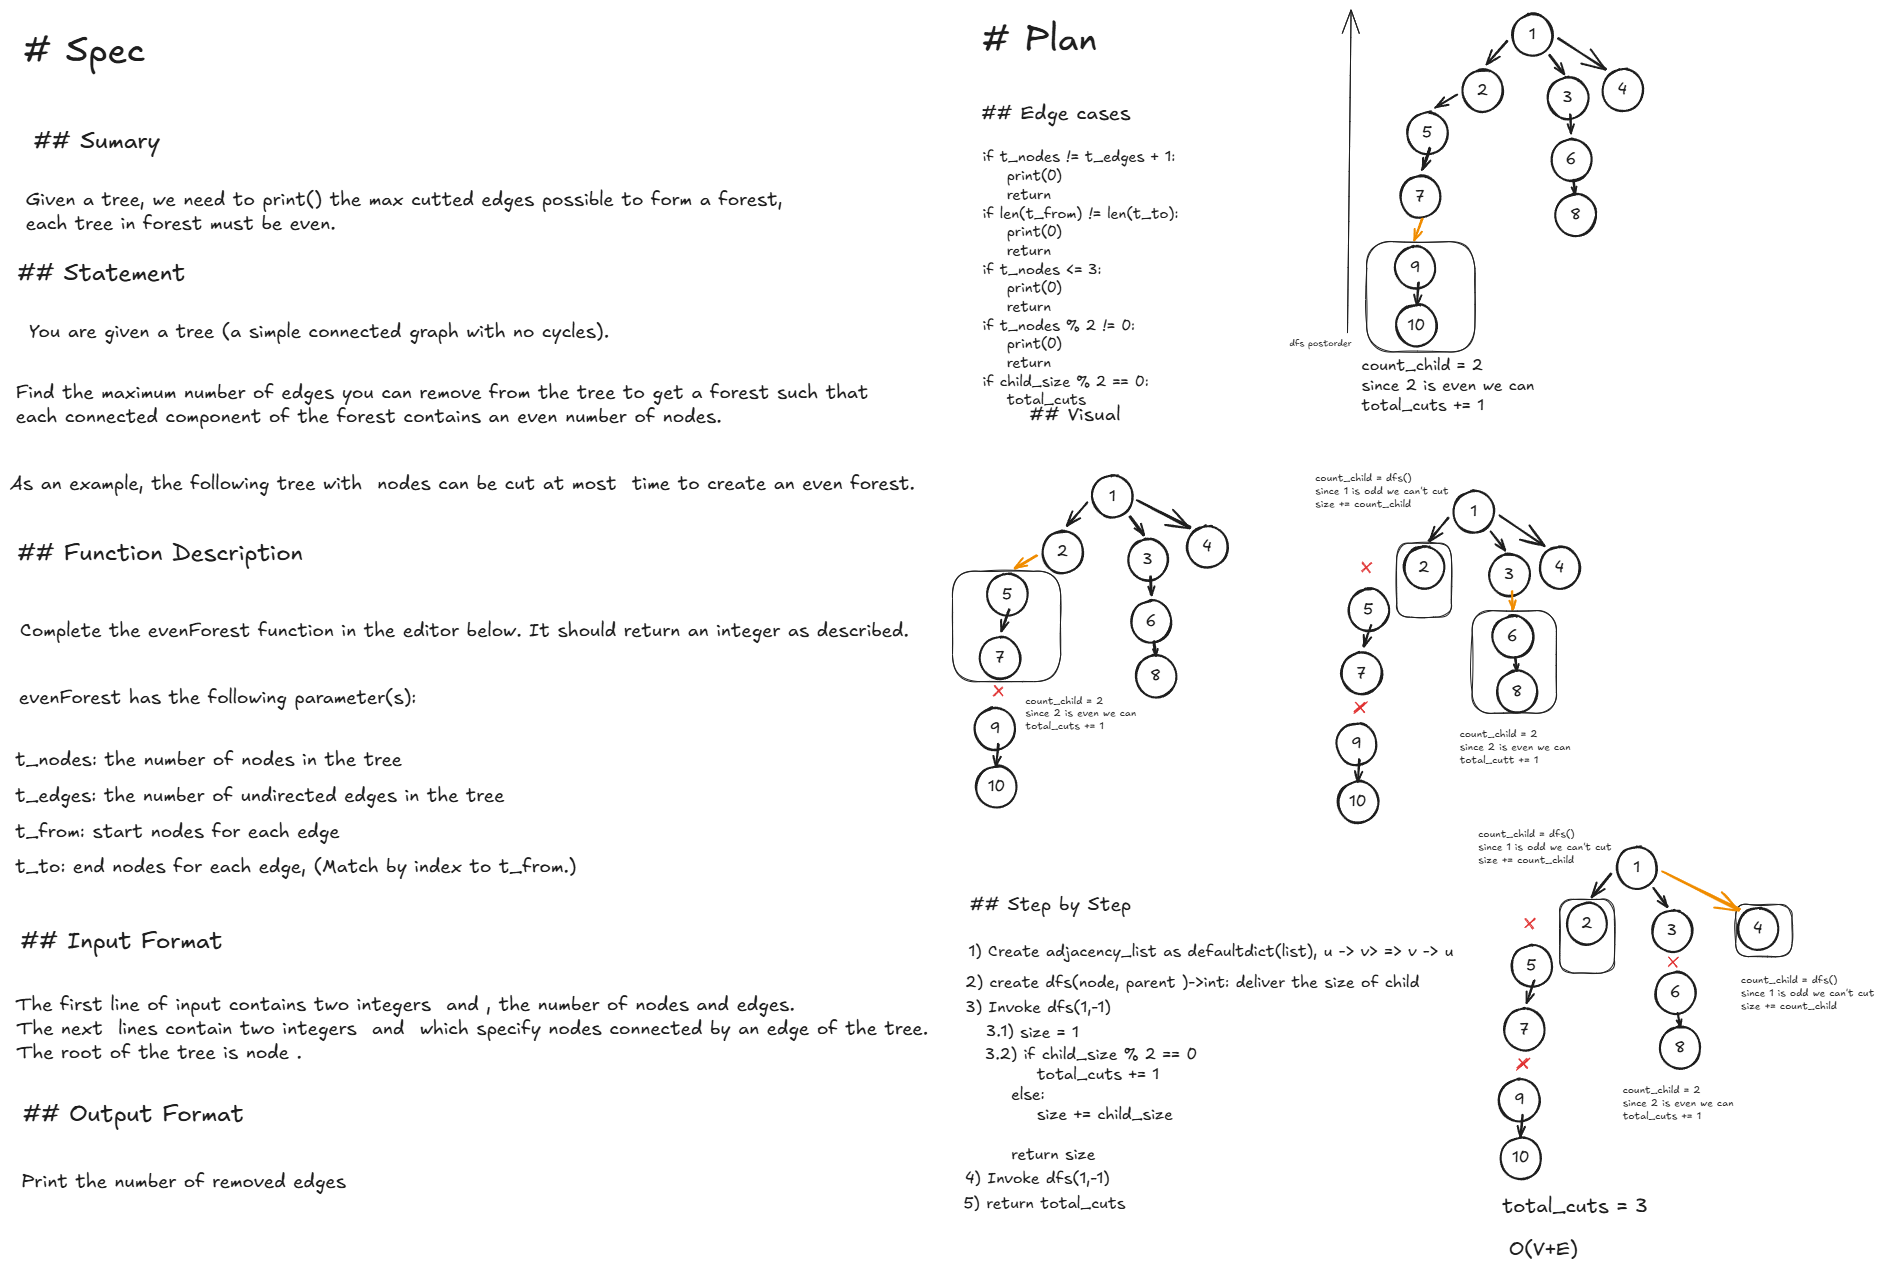

In [ ]:


import math
import os
import random
import re
from collections import defaultdict
from typing import List, Tuple
import sys


import sys


sys.setrecursionlimit(10**5)

def evenForest(t_nodes, t_edges, t_from, t_to):
    if t_nodes % 2 == 1:
        return 0

    adj = [[] for _ in range(t_nodes + 1)]
    for u, v in zip(t_from, t_to):
        adj[u].append(v)
        adj[v].append(u)

    total_cuts = 0

    def dfs(node, parent):
        nonlocal total_cuts 
        size = 1
        
        for neighbor in adj[node]:
            if neighbor == parent:
                continue
            
            child_size = dfs(neighbor, node)
            
            if child_size % 2 == 0:
                total_cuts += 1
            else:
                size += child_size
                
                
        return size

    dfs(1, -1)
    return total_cuts

if __name__ == '__main__':
    sys.setrecursionlimit(10**5)
    fptr = open(os.environ['OUTPUT_PATH'], 'w')

    t_nodes, t_edges = map(int, input().rstrip().split())

    t_from = [0] * t_edges
    t_to = [0] * t_edges

    for i in range(t_edges):
        t_from[i], t_to[i] = map(int, input().rstrip().split())

    res = evenForest(t_nodes, t_edges, t_from, t_to)

    fptr.write(str(res) + '\n')

    fptr.close()
